In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yashpaloswal/ann-car-sales-price-prediction/car_purchasing.csv


In [37]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA available: True


In [38]:
DATA_PATH   = "/kaggle/input/datasets/yashpaloswal/ann-car-sales-price-prediction/car_purchasing.csv"
TARGET_COL  = "car purchase amount"          # Continuous regression target (55–101)
TEST_SIZE   = 0.10                  # 10% test
VAL_SIZE    = 0.11                  # ~10% of total (11% of remaining 90%)
RANDOM_SEED = 42
BATCH_SIZE  = 64
EPOCHS      = 100
LR          = 1e-3
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")


Using device: cuda


In [39]:
df = pd.read_csv(DATA_PATH, encoding='latin1')
print(f"Dataset shape: {df.shape}")
print(f"\nTarget stats:\n{df[TARGET_COL].describe()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nData types:\n{df.dtypes}")

Dataset shape: (500, 9)

Target stats:
count      500.000000
mean     44209.799218
std      10773.178744
min       9000.000000
25%      37629.896040
50%      43997.783390
75%      51254.709517
max      80000.000000
Name: car purchase amount, dtype: float64

Missing values:
Series([], dtype: int64)

Data types:
customer name           object
customer e-mail         object
country                 object
gender                   int64
age                    float64
annual Salary          float64
credit card debt       float64
net worth              float64
car purchase amount    float64
dtype: object


In [40]:
print(df.columns.tolist())


['customer name', 'customer e-mail', 'country', 'gender', 'age', 'annual Salary', 'credit card debt', 'net worth', 'car purchase amount']


In [41]:
binary_maps = {
    "customer name": {"No": 0, "Yes": 1},
    "customer e-mail":            {"No": 0, "Yes": 1},
    "country":      {"No": 0, "Yes": 1},
}
for col, mapping in binary_maps.items():
    df[col] = df[col].map(mapping)

print("Encoding complete. Sample:")
print(df.head(3))

Encoding complete. Sample:
   customer name  customer e-mail  country  gender        age  annual Salary  \
0            NaN              NaN      NaN       0  41.851720    62812.09301   
1            NaN              NaN      NaN       0  40.870623    66646.89292   
2            NaN              NaN      NaN       1  43.152897    53798.55112   

   credit card debt    net worth  car purchase amount  
0      11609.380910  238961.2505          35321.45877  
1       9572.957136  530973.9078          45115.52566  
2      11160.355060  638467.1773          42925.70921  


In [42]:
null_cols = ["customer name", "customer e-mail", "country"]

for col in null_cols:
    # Pehle check karein agar mode exist karta hai (yaani column bilkul khali nahi hai)
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Agar pura column hi NaN hai, to use filhal "Unknown" se fill kar dein
        df[col] = df[col].fillna("Unknown")

print("Nulls after fill:", df.isnull().sum().sum())


Nulls after fill: 0


In [46]:
# Teeno columns mein 'Unknown' ko 'Missing' ya 'None' se replace karein
text_cols = ['country', 'customer e-mail', 'customer name'] # Apne exact column names likhein
df[text_cols] = df[text_cols].replace('Unknown', 'Missing')


In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. 'Unknown' ko replace karein
text_cols = ['country', 'customer e-mail', 'customer name']
df[text_cols] = df[text_cols].replace('Unknown', 'Missing')

# 2. Text ko Numbers mein badlein (Label Encoding)
le = LabelEncoder()
for col in text_cols:
    df[col] = le.fit_transform(df[col].astype(str))



In [48]:
FEATURES = [c for c in df.columns if c != TARGET_COL]

# FIX #8: Explicit numpy conversion before tensor creation
X = df[FEATURES].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32).reshape(-1, 1)

print(f"Features: {len(FEATURES)} → {FEATURES}")
print(f"X shape: {X.shape} | y shape: {y.shape}")

Features: 8 → ['customer name', 'customer e-mail', 'country', 'gender', 'age', 'annual Salary', 'credit card debt', 'net worth']
X shape: (500, 8) | y shape: (500, 1)


In [49]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=RANDOM_SEED
)

print(f"Train : {len(X_train):>5} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val   : {len(X_val):>5} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test):>5} ({len(X_test)/len(X)*100:.0f}%)")

Train :   400 (80%)
Val   :    50 (10%)
Test  :    50 (10%)


In [50]:
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

# FIX #9: Scale target with StandardScaler, NOT LabelEncoder
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train)   # shape (N, 1)
y_val_s   = scaler_y.transform(y_val)

print("Scaling done — X mean≈0, std≈1 ✓")

Scaling done — X mean≈0, std≈1 ✓


In [52]:
def to_tensors(X, y):
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),  # float32, shape (N,1)
    )

X_tr, y_tr = to_tensors(X_train_s, y_train_s)
X_vl, y_vl = to_tensors(X_val_s,   y_val_s)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} × batch_size={BATCH_SIZE}")
print(f"Val   batches: {len(val_loader)}")

Train batches: 7 × batch_size=64
Val   batches: 1


In [53]:
class  ANN_carsales(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            # Block 1 — wide entry layer
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Block 2
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            # # Block 3
            # nn.Linear(128, 64),
            # nn.BatchNorm1d(64),
            # nn.ReLU(),
            # nn.Dropout(0.2),

            # Output: single neuron for regression
            nn.Linear(32, 1),            # FIX #12: 1, NOT num_classes
        )

    def forward(self, x):
        return self.network(x)


model = ANN_carsales(input_dim=X_train_s.shape[1]).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

ANN_carsales(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 2,881


In [54]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# FIX #15: min_lrs (list) is the correct kwarg for ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
)

print("Loss  : MSELoss")
print("Optim : AdamW  lr={}".format(LR))
print("Sched : ReduceLROnPlateau")

Loss  : MSELoss
Optim : AdamW  lr=0.001
Sched : ReduceLROnPlateau


In [55]:
history = {"train_loss": [], "val_loss": [], "train_rmse": [], "val_rmse": []}
best_val_loss    = float("inf")
best_state       = None
patience_counter = 0
PATIENCE         = 20

std_y = scaler_y.scale_[0]   # used to convert scaled RMSE → original units

print(f"{'Epoch':>6} | {'Train RMSE':>10} | {'Val RMSE':>10} | {'LR':>9}")
print("-" * 48)

for epoch in range(1, EPOCHS + 1):

    # ── Train ──
    model.train()
    total_loss, total_n = 0.0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
        total_n    += len(yb)
    avg_train_loss = total_loss / total_n

    # ── Validate ──
    model.eval()
    val_loss, val_n = 0.0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(Xb), yb).item() * len(yb)
            val_n    += len(yb)
    avg_val_loss = val_loss / val_n

    # FIX #15: scheduler.step receives val loss (not train loss)
    scheduler.step(avg_val_loss)

    train_rmse = np.sqrt(avg_train_loss) * std_y
    val_rmse   = np.sqrt(avg_val_loss)   * std_y
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_rmse"].append(train_rmse)
    history["val_rmse"].append(val_rmse)

    # Early stopping + save best
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        best_state       = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"{epoch:>6} | {train_rmse:>10.4f} | {val_rmse:>10.4f} | {lr_now:>9.6f}")


 Epoch | Train RMSE |   Val RMSE |        LR
------------------------------------------------
     1 | 10917.7045 |  8629.2148 |  0.001000
    10 |  4468.2967 |  1763.9205 |  0.001000
    20 |  4477.5504 |  1252.0199 |  0.001000
    30 |  3521.5434 |  1490.9696 |  0.000500
    40 |  3363.8986 |   873.9221 |  0.000500
    50 |  3500.7656 |  1259.6268 |  0.000500

Early stopping at epoch 60


In [56]:
torch.save({
    "model_state":    best_state,
    "scaler_X_mean":  scaler_X.mean_,
    "scaler_X_std":   scaler_X.scale_,
    "scaler_y_mean":  scaler_y.mean_,
    "scaler_y_std":   scaler_y.scale_,
    "feature_names":  FEATURES,
}, "/kaggle/working/best_student_model.pt")
print("Model saved to /kaggle/working/best_student_model.pt")

Model saved to /kaggle/working/best_student_model.pt


In [62]:
model.load_state_dict(best_state)
model.eval()

X_test_t = torch.tensor(X_test_s, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    preds_scaled = model(X_test_t).cpu().numpy()

preds   = scaler_y.inverse_transform(preds_scaled)   # back to original scale
actuals = y_test

mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
r2   = r2_score(actuals, preds)

print("\n" + "=" * 40)
print("  TEST RESULTS")
print("=" * 40)
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

print("\nSample predictions vs actuals (first 10):")
print(f"{'Predicted':>12} {'Actual':>10} {'Error':>8}")
print("-" * 34)
for p, a in zip(preds[:10], actuals[:10]):
    print(f"{p[0]:>12.2f} {a[0]:>10.2f} {abs(p[0]-a[0]):>8.2f}")


  TEST RESULTS
  MAE  : 544.8850
  RMSE : 724.4543
  R²   : 0.9949

Sample predictions vs actuals (first 10):
   Predicted     Actual    Error
----------------------------------
    45907.47   46082.81   175.34
    45089.00   45058.90    30.11
    62121.42   63079.84   958.43
    33037.17   31837.22  1199.94
    60154.57   60461.24   306.67
    61612.04   63140.05  1528.02
    51995.22   52477.84   482.62
    54653.72   54755.42   101.70
    52526.11   52707.97   181.86
    48123.89   47869.82   254.07


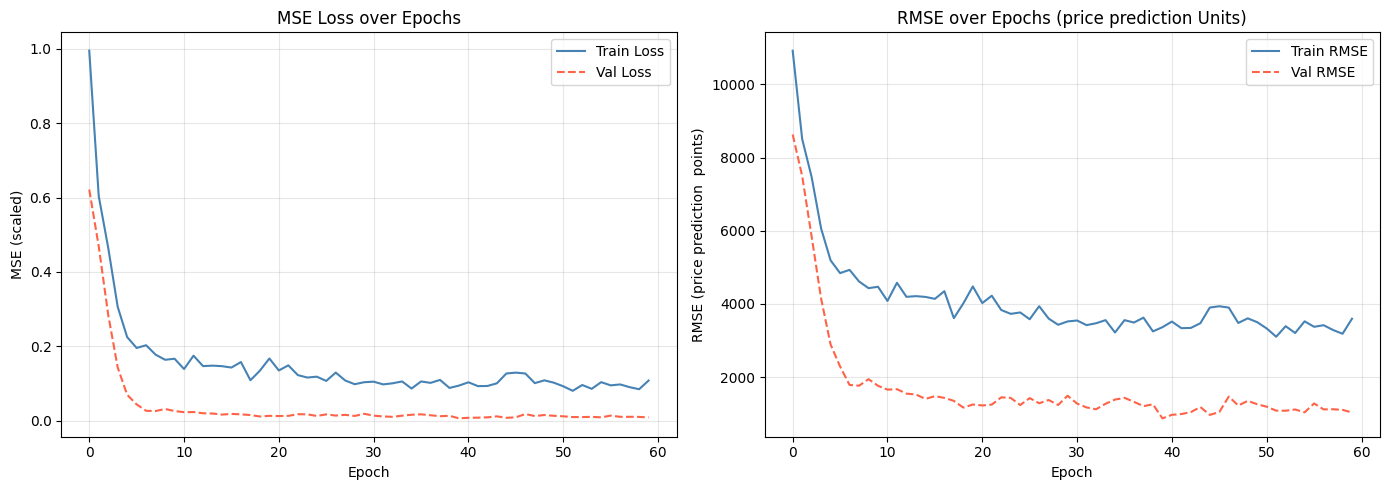

Plot saved to /kaggle/working/training_curves.png


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(history["val_loss"],   label="Val Loss",   color="tomato", linestyle="--")
axes[0].set_title("MSE Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (scaled)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# RMSE in original units
axes[1].plot(history["train_rmse"], label="Train RMSE", color="steelblue")
axes[1].plot(history["val_rmse"],   label="Val RMSE",   color="tomato", linestyle="--")
axes[1].set_title("RMSE over Epochs (price prediction Units)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE (price prediction  points)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()
print("Plot saved to /kaggle/working/training_curves.png")